In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import os, sys
sys.path.append(os.path.abspath("../src"))
from io_utils import load_data
from health_study import HealthStudyAnalizer
df = load_data()
df_clean = HealthStudyAnalizer(df).clean_df()


# Beskrivande analys – Grundläggande statistik

In [19]:
cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]
stats = df_clean[cols].agg(["mean", "median", "min", "max"]).round(2)
stats

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


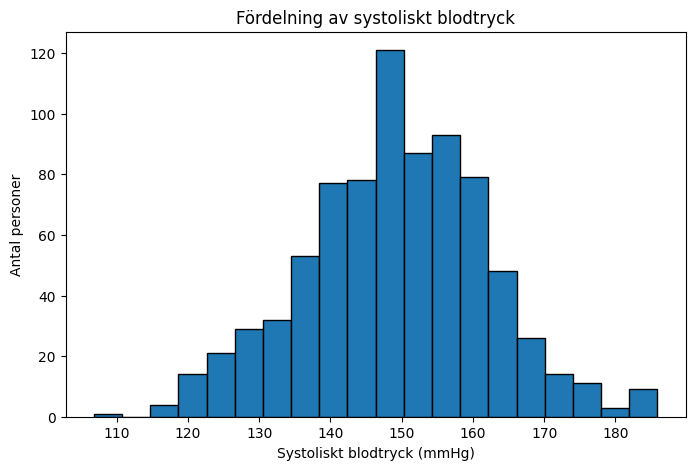

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['systolic_bp'], bins=20, edgecolor='black')
plt.title("Fördelning av systoliskt blodtryck")
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal personer")
plt.show()

### Fördelningen av systoliskt blodtryck
- Diagrammet visar att de flesta personer har ett systoliskt blodtryck mellan 135 och 165 mmHg.
- Majoriteten ligger runt 145–150 mmHg, vilket visar den vanligaste nivån i gruppen.

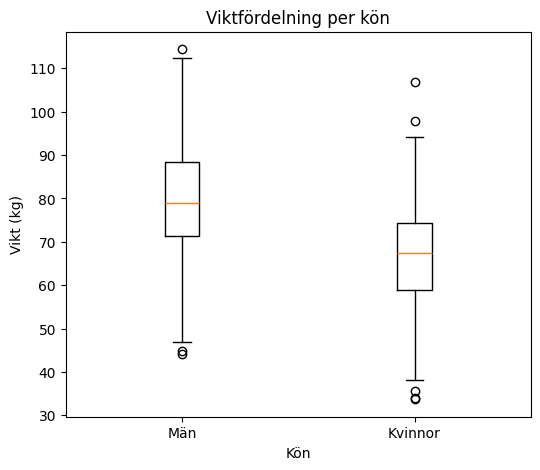

In [24]:
plt.figure(figsize=(6,5))
plt.boxplot([df_clean[df_clean['sex']=='M']['weight'],
             df_clean[df_clean['sex']=='F']['weight']],
            tick_labels=['Män', 'Kvinnor'])
plt.title("Viktfördelning per kön")
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.show()

### Viktfördelning per kön
- Diagrammet visar att män i genomsnitt väger mer än kvinnor.
- Medianvikten för män ligger runt 78–80 kg, medan kvinnors medianvikt ligger runt 65–68 kg.
- Spridningen är också något större bland män.
- Några outliers finns för båda könen, både lägre och högre vikter än genomsnittet.

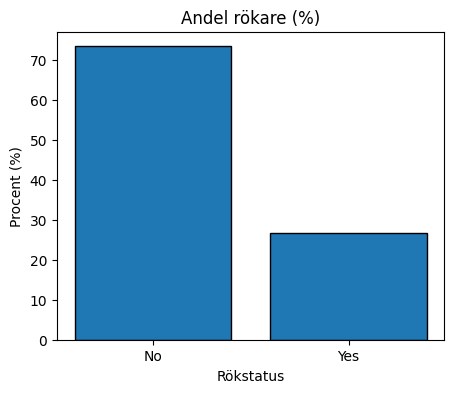

In [25]:
smoker_counts = df_clean['smoker'].value_counts(normalize=True) * 100
plt.figure(figsize=(5,4))
plt.bar(smoker_counts.index, smoker_counts.values, edgecolor='black')
plt.title("Andel rökare (%)")
plt.ylabel("Procent (%)")
plt.xlabel("Rökstatus")
plt.show()

### Andelen rökare
- Diagrammet visar att majoriteten av populationen inte röker, vilket kan ha en positiv inverkan på deras hälsa.

# Simulering och jämförelse av sjukdomsandel

In [66]:
disease_rate = df_clean["disease"].value_counts(normalize=True)[1]
disease_rate_percent = disease_rate * 100
print(f"Andelen personer med sjukdom: {disease_rate_percent:.2f}%")
np.random.seed(42)
simulated = np.random.binomial(1, disease_rate, size=1000)
simulated_rate = simulated.mean()
print(f"Andelen personer med sjukdom i simuleringen: {simulated_rate:.2%}")

Andelen personer med sjukdom: 5.88%
Andelen personer med sjukdom i simuleringen: 5.60%


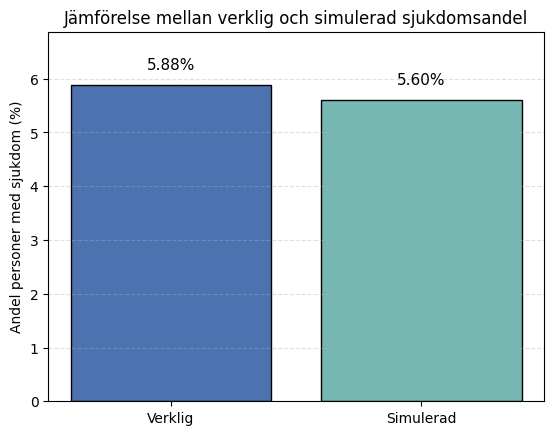

In [87]:
labels = ['Verklig', 'Simulerad']
values = [disease_rate_percent, simulated_rate * 100] 
plt.bar(labels, values, color=['#4C72B0', '#76B7B2'], edgecolor='black', linewidth=1)
plt.ylabel('Andel personer med sjukdom (%)')
plt.title('Jämförelse mellan verklig och simulerad sjukdomsandel')
plt.ylim(0, max(values) + 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(values):
    plt.text(i, v+0.3, f"{v:.2f}%", ha='center', fontsize=11)
plt.show()